In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
%matplotlib inline
import getdist
from getdist import loadMCSamples, plots
import warnings
from copy import deepcopy

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# GENERAL PLOT OPTIONS
# GENERAL PLOT OPTIONS
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['ytick.major.size'] = 6
matplotlib.rcParams['ytick.major.width'] = 1.2
matplotlib.rcParams['ytick.minor.size'] = 3
matplotlib.rcParams['ytick.minor.width'] = 0.8
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 24
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['legend.fontsize'] = 14
matplotlib.rcParams['legend.title_fontsize'] = 18
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.dpi'] = 300

columnwidth=246/72.27
textwidth=510/72.27

matplotlib.rcParams['axes.titlesize'] = 10
matplotlib.rcParams['axes.labelsize'] = 10
matplotlib.rcParams['legend.fontsize'] = 10
matplotlib.rcParams['legend.title_fontsize'] = 10
matplotlib.rcParams['xtick.labelsize'] = 10
matplotlib.rcParams['ytick.labelsize'] = 10

from scipy.interpolate import interp1d
from scipy.integrate import quad

In [2]:
import numpy as np
import matplotlib.pyplot as plt

cols = [
    'As_1e9', 'ns', 'H0', 'omegab', 'omegam', 'omegach2', 'w0pwa', 'w',
    'xi+', 'xi+_msk', 'xi-', 'xi-_msk',
    'gammat', 'gammat_msk', 'wtheta', 'wtheta_msk', 'msk'
]

data = np.loadtxt('./data/chis.txt')
keys = np.loadtxt('./data/1.txt')

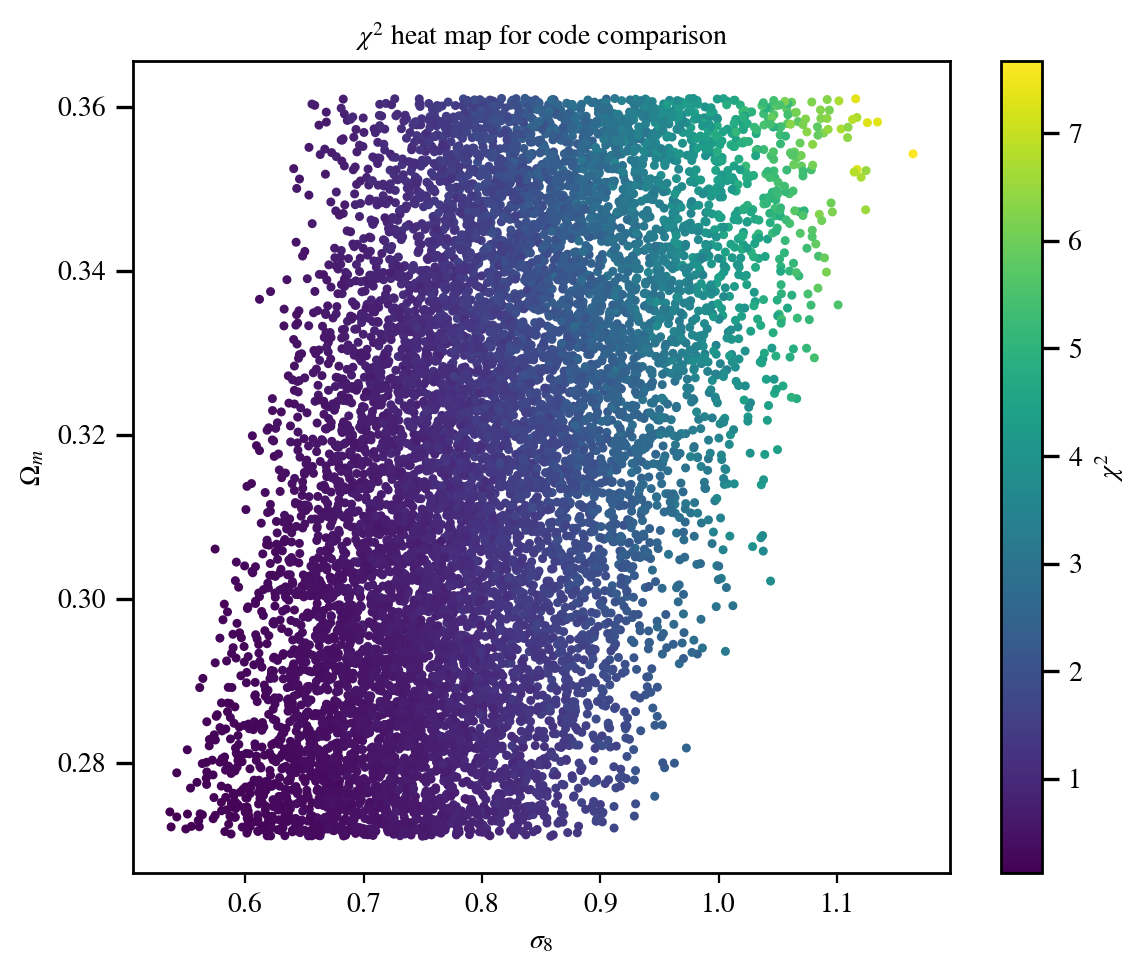

In [6]:
h = data[:, 2]/100
#omegam = (omegam-omegab)*(H0/100)**2-(mnu*(3.046/3)**0.75)/94.0708
omegam = keys[:, 6]
sigma8 = keys[:, 54]
chi2_msk = data[:, 8]+data[:,10]

plt.figure(figsize=(6,5))
sc = plt.scatter(
    sigma8, omegam,
    c = chi2_msk,
    s = 5,
    cmap = 'viridis'
)
plt.xlabel(r'$\sigma_8$')
plt.ylabel(r'$\Omega_m$')
plt.colorbar(sc, label=r'$\chi^2$')
plt.title(r'$\chi^2$ heat map for code comparison')
plt.tight_layout()
plt.show()

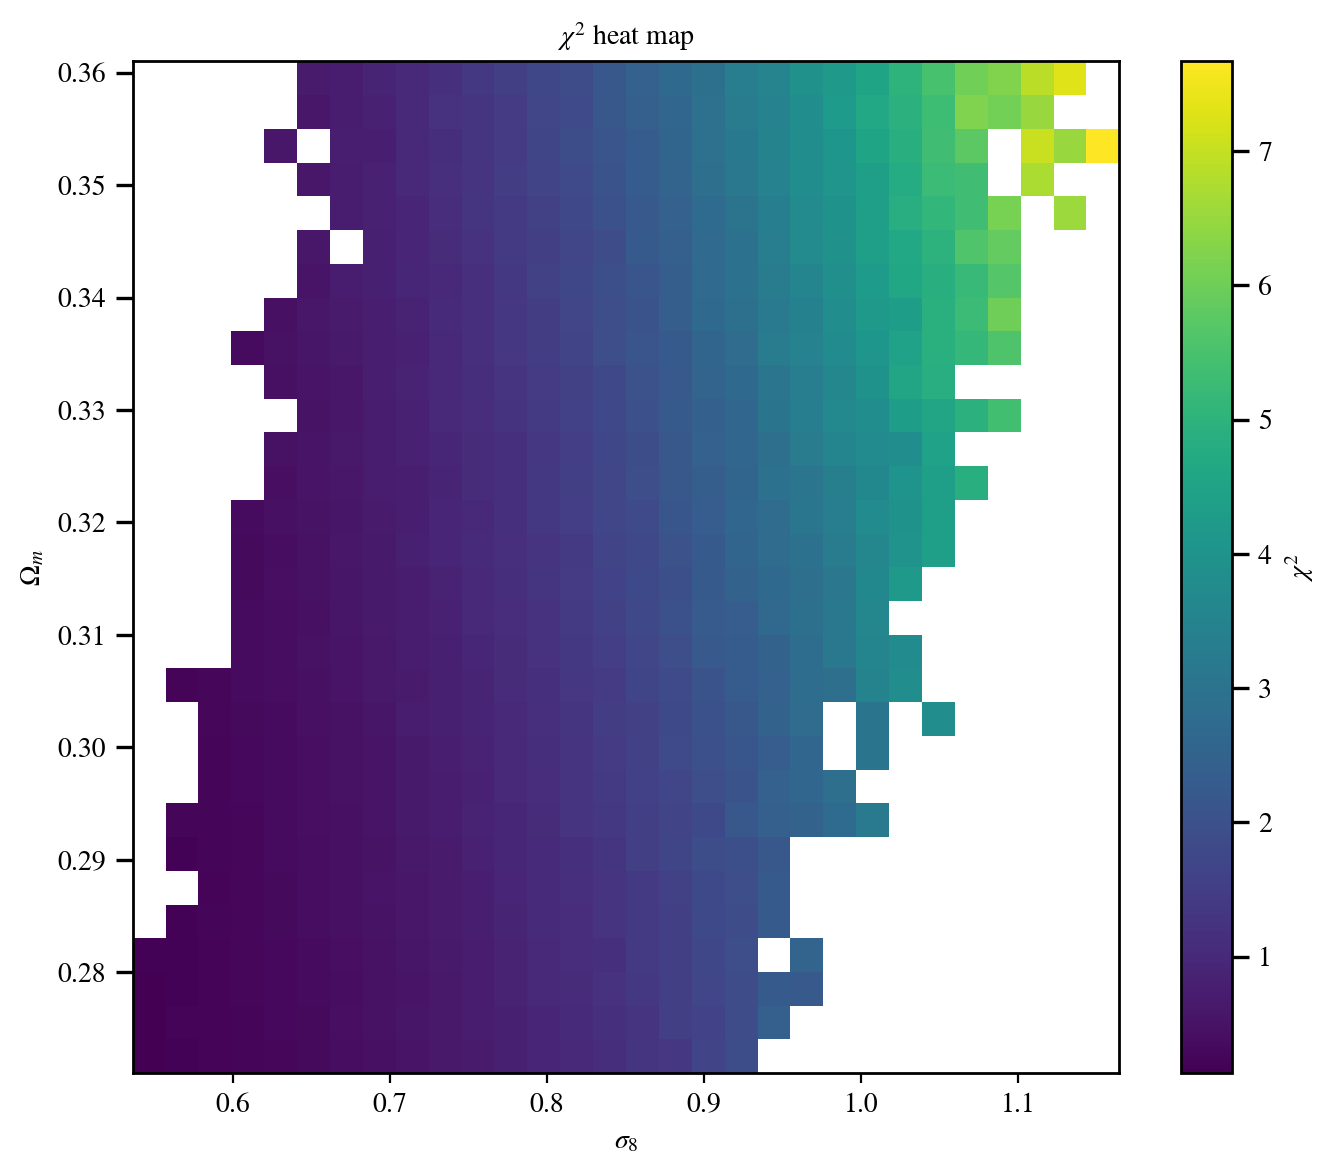

In [7]:
from scipy.stats import binned_statistic_2d

stat, x_edge, y_edge, binnumber = binned_statistic_2d(
    sigma8, omegam, chi2_msk,
    statistic='mean', 
    bins=30
)
plt.figure(figsize=(textwidth,6))
pcm = plt.pcolormesh(x_edge, y_edge, stat.T, shading='auto', cmap='viridis')

plt.xlabel(r'$\sigma_8$')
plt.ylabel(r'$\Omega_m$')
plt.colorbar(pcm, label=r'$\chi^2$')
plt.title(r'$\chi^2$ heat map')
plt.tight_layout()
plt.show()

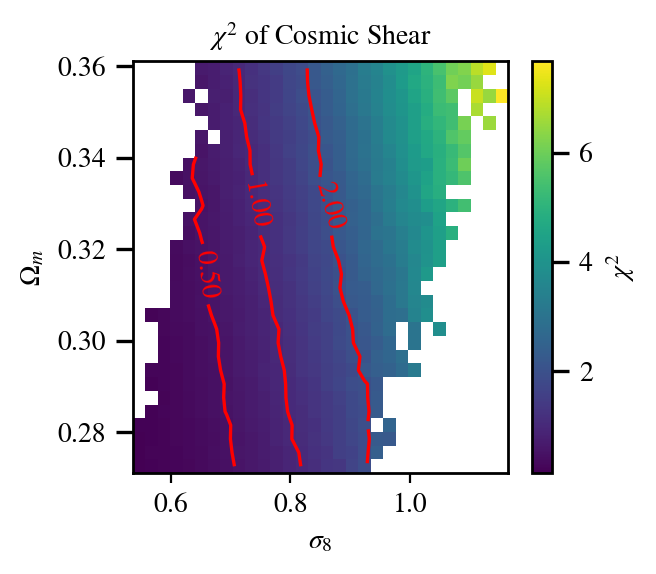

In [16]:
from scipy.stats import binned_statistic_2d
import numpy as np
import matplotlib.pyplot as plt

stat, x_edge, y_edge, binnumber = binned_statistic_2d(
    sigma8, omegam, chi2_msk,
    statistic='mean',
    bins=30
)

# bin centers
x_center = 0.5 * (x_edge[:-1] + x_edge[1:])
y_center = 0.5 * (y_edge[:-1] + y_edge[1:])
Xc, Yc = np.meshgrid(x_center, y_center, indexing='xy')

plt.figure(figsize=(columnwidth, 3))

# heat map
pcm = plt.pcolormesh(x_edge, y_edge, stat.T, shading='auto', cmap='viridis')

# contour levels，可自己改
levels = [0.5, 1, 2]
#levels = [0.03]

# 画等高线
cs = plt.contour(Xc, Yc, stat.T, levels=levels, colors='red', linewidths=1.2)

# 给等高线标数值
plt.clabel(cs, inline=True, fontsize=10, fmt='%.2f')

plt.xlabel(r'$\sigma_8$')
plt.ylabel(r'$\Omega_m$')
plt.colorbar(pcm, label=r'$\chi^2$')
plt.title(r'$\chi^2$ of Cosmic Shear')
plt.tight_layout()
#plt.show()

plt.savefig('chi2_cosmic_shear_over_cosmology.pdf', dpi=300)